### [GitHub](https://github.com/msultanmahmud/Stress_WESAD/blob/master/Multiclass_Pipeline_Individual_sub_INTEC.ipynb)

In [ ]:
# ! pip list

In [ ]:
# ! pip install lightgbm

In [3]:
import numpy as np
import pandas as pd
import os
import sys
import random
import warnings
warnings.filterwarnings('ignore')
import pickle
from sklearn.model_selection import train_test_split
from sklearn import svm, metrics,preprocessing
#from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_curve, auc,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_predict
from matplotlib import pyplot as plt
from collections import Counter
from scipy.stats import norm
import seaborn as sns; sns.set(font_scale=1.2)
%matplotlib inline
import time
import xgboost as xgb
import lightgbm as lgb

#### Redaing file

In [5]:
df=pd.read_csv('../dreamt_preprocessed.csv')
df.subject.nunique()

100

In [6]:
# Identify columns to drop if they exist
columns_to_drop = [col for col in df.columns if 'skewness' in col.lower() or 'kurtosis' in col.lower()]

# Drop only those columns that actually exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
df.head(5) 

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.0625,1.0625,1.0625,0.0,1.0625,1.0625,1.0625,1.0625,1.0625


### Drop subject those who have some data Msisning 

In [8]:
df = df[~df['subject'].isin(['S062', 'S097'])]
pre_procss_all=df.copy()
pre_procss_all

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
0,S002,1,3.0,-0.000008,0.000008,6.380306e-09,0.000002,-0.000004,-1.318379e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
1,S002,2,3.0,-0.000006,0.000005,4.531319e-08,0.000002,-0.000003,-1.123064e-06,-4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
2,S002,3,3.0,-0.000004,0.000005,4.547595e-08,0.000002,-0.000002,-9.277485e-07,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
3,S002,4,3.0,-0.000017,0.000019,6.071056e-08,0.000003,-0.000004,-1.220722e-06,1.464866e-07,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
4,S002,5,3.0,-0.000008,0.000009,6.067801e-08,0.000002,-0.000004,-1.416037e-06,4.882887e-08,...,72.85,1.062500,1.062500,1.062500,0.000000,1.062500,1.062500,1.062500,1.062500,1.062500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95142,S103,899,1.0,-0.000025,0.000045,2.679077e-08,0.000008,-0.000012,-4.638743e-06,-1.464866e-07,...,72.12,0.859375,0.906250,0.884599,0.016580,0.859375,0.859375,0.890625,0.890625,0.906250
95143,S103,900,1.0,-0.000035,0.000032,1.027685e-07,0.000008,-0.000014,-4.638743e-06,1.464866e-07,...,68.87,0.812500,0.890625,0.869016,0.019533,0.828125,0.859375,0.859375,0.890625,0.890625
95144,S103,901,1.0,-0.000083,0.000080,1.070654e-07,0.000011,-0.000013,-4.541085e-06,3.906310e-07,...,69.03,0.843750,0.906250,0.871021,0.019181,0.843750,0.859375,0.875000,0.875000,0.906250
95145,S103,902,1.0,-0.000049,0.000056,8.274866e-08,0.000009,-0.000013,-4.931716e-06,1.464866e-07,...,69.42,0.734375,0.937500,0.869594,0.061489,0.734375,0.875000,0.890625,0.906250,0.921875


In [10]:
df_fusion_cleaned = pre_procss_all[pre_procss_all['label'].isin([0,1,2])]
df_fusion_cleaned

### How many subjec
sample=df_fusion_cleaned.subject.unique()[:15]
# # Sample the data (if needed)
df_sample = df_fusion_cleaned[df_fusion_cleaned.subject.isin(sample)]
df_sample

,subject,epoch,label,C4-M1_min,C4-M1_max,C4-M1_mean,C4-M1_std,C4-M1_p5,C4-M1_p25,C4-M1_p50,...,HR_p95,IBI_min,IBI_max,IBI_mean,IBI_std,IBI_p5,IBI_p25,IBI_p50,IBI_p75,IBI_p95
305,S002,307,0.0,-0.000043,0.000020,-2.770550e-07,0.000007,-0.000010,-0.000003,4.394598e-07,...,81.62,0.937500,0.953125,0.952734,0.002440,0.953125,0.953125,0.953125,0.953125,0.953125
306,S002,308,0.0,-0.000018,0.000014,6.477963e-09,0.000005,-0.000007,-0.000003,4.882887e-08,...,85.00,0.953125,0.953125,0.953125,0.000000,0.953125,0.953125,0.953125,0.953125,0.953125
307,S002,309,0.0,-0.000050,0.000046,2.981816e-08,0.000008,-0.000011,-0.000003,2.441444e-07,...,82.45,0.812500,0.953125,0.823187,0.037272,0.812500,0.812500,0.812500,0.812500,0.953125
308,S002,310,0.0,-0.000018,0.000017,1.591821e-08,0.000005,-0.000008,-0.000003,4.882887e-08,...,85.88,0.812500,0.812500,0.812500,0.000000,0.812500,0.812500,0.812500,0.812500,0.812500
309,S002,311,0.0,-0.000052,0.000067,1.513695e-07,0.000010,-0.000017,-0.000003,4.394598e-07,...,87.73,0.765625,0.968750,0.781552,0.046296,0.765625,0.765625,0.765625,0.765625,0.953125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14155,S016,1065,1.0,-0.000049,0.000041,-1.360698e-08,0.000010,-0.000016,-0.000006,-2.441444e-07,...,61.35,0.859375,1.187500,0.972151,0.091068,0.875000,0.875000,1.031250,1.046875,1.046875
14156,S016,1067,2.0,-0.000027,0.000026,7.278757e-08,0.000007,-0.000011,-0.000004,4.882887e-08,...,59.03,0.812500,1.125000,1.024130,0.133572,0.812500,0.890625,1.125000,1.125000,1.125000
14157,S016,1068,2.0,-0.000066,0.000066,4.059958e-07,0.000016,-0.000024,-0.000006,9.765774e-08,...,59.35,0.906250,1.140625,1.030818,0.101451,0.921875,0.937500,0.953125,1.140625,1.140625
14158,S016,1069,2.0,-0.000034,0.000037,-2.882205e-07,0.000008,-0.000013,-0.000005,-1.464866e-07,...,59.02,0.828125,1.281250,1.099229,0.168746,0.937500,0.937500,0.984375,1.281250,1.281250


In [12]:
# df1=df_fusion_cleaned.copy()
# df1.head(3)

## Reading the stability score pickle that was save during the satability selection analysis

In [17]:
# with open("results_ss_v1.pkl", "rb") as f:
with open("stability_score_alpha_fusion_v2.pkl", "rb") as f:
    results = pickle.load(f)
results.keys()

dict_keys([0.001, 0.01, 0.02, 0.04, 0.05, 0.07, 0.75, 1.0])

In [19]:
# # Define the keys you want to keep
# keep_alphas = [0.001, 0.01, 0.02, 0.04, 0.05, 0.07]

# # Filter the dictionary
# results_filtered = {k: v for k, v in results.items() if k in keep_alphas}
# results_filtered
# import pickle
# with open("stability_score_alpha_whole_v1.pkl", "wb") as f:
#     pickle.dump(results_filtered, f)


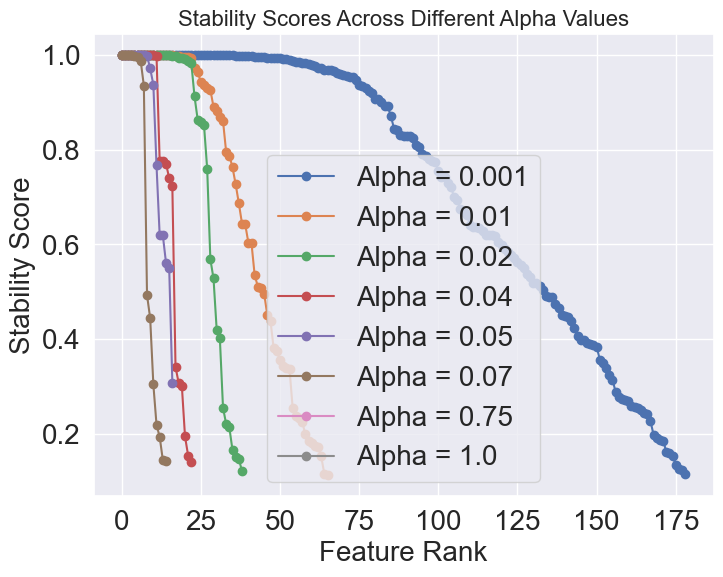

In [21]:
# Plot stability scores for each alpha
fs=20
plt.figure(figsize=(8, 6))

for alpha, df_alpha in results.items():
    filtered_df = df_alpha[df_alpha['Stability_Score'] >= 0.1]
    plt.plot(range(len(filtered_df)), filtered_df['Stability_Score'], label=f'Alpha = {alpha}', marker='o')

plt.title('Stability Scores Across Different Alpha Values',fontsize=16)
plt.xlabel('Feature Rank',fontsize=fs)
plt.ylabel('Stability Score',fontsize=fs)
plt.xticks(fontsize=fs)  # Make x-axis tick labels larger
plt.yticks(fontsize=fs)  # Make y-axis tick labels larger
plt.legend(fontsize=fs,loc='lower center')
plt.grid(True)
plt.show()

In [23]:
feature_importance_df_07=results[0.07][results[0.07].Stability_Score>=0.7]['Feature'].values
sel_col=np.append(feature_importance_df_07,'label')
### Selected features only
df1=df_sample[sel_col]
df1.head(3)

,ABDOMEN_min,ACC_Z_std,CHIN_p25,BVP_min,ACC_X_std,RAT_max,ACC_Y_std,ECG_min,label
305,-0.000471,3.365642,-0.000004,-1257.38,3.628029,0.000047,1.279327,-0.000207,0.0
306,-0.000599,2.256455,-0.000004,-749.06,1.299924,0.000012,0.455387,-0.000223,0.0
307,-0.000575,1.113902,-0.000004,-281.51,0.837405,0.000019,0.268644,-0.000250,0.0


In [25]:
#   df_sample.subject.nunique()

### Classification based on the selected Features

In [29]:
# !jupyter kernelspec list

In [31]:
from joblib import Parallel, delayed
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
import pandas as pd
import numpy as np

def preprocess_scaling(df):
    '''Scales features and splits into train/test.'''
    X = df.drop(columns=['label'])
    y = df['label']
    X_scaled = preprocessing.scale(X)
    return train_test_split(X_scaled, y, test_size=0.2, random_state=42)

def train_and_evaluate(model, X_train, y_train, X_test, y_test, model_name, auc_mode='ovr'):
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

        # AUC calculation — multi-class
        if hasattr(model, "predict_proba"):
            y_probs = model.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None  # SVM without probability=True will not support this

        return (model_name, acc, f1, precision, recall, auc)
    except Exception as e:
        print(f"Error with model {model_name}: {e}")
        return (model_name, None, None, None, None, None)

def multiple_model(df, auc_mode='ovr'):
    X_train, X_test, y_train, y_test = preprocess_scaling(df)
    model_name_list = ['KNN', 'DT', 'XGBoost', 'LightGBM', 'RF', 'SVM']

    # SVM needs probability=True for predict_proba
    models = [
        KNeighborsClassifier(metric='minkowski', n_neighbors=2, weights='distance', p=2),
        DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50),
        xgb.XGBClassifier(objective='multi:softprob', num_class=len(np.unique(y_train)), random_state=42,
                          max_depth=15, learning_rate=0.3, gamma=0.2, colsample_bytree=0.7,
                          min_child_weight=1, eval_metric='mlogloss', n_jobs=-1),
        lgb.LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=100,
                           min_child_weight=0.5, n_estimators=200, verbose=-1, n_jobs=-1),
        RandomForestClassifier(max_depth=40, max_features='log2', n_estimators=200, n_jobs=-1),
        svm.SVC(C=10, kernel='rbf', degree=3, gamma=0.1, probability=True)  # Required for AUC
    ]

    results_list = Parallel(n_jobs=-1)(delayed(train_and_evaluate)(
        model, X_train, y_train, X_test, y_test, name, auc_mode
    ) for model, name in zip(models, model_name_list))

    results_df = pd.DataFrame(results_list, columns=['Model', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUC'])
    results_df.set_index('Model', inplace=True)
    results_df=results_df[['Accuracy','AUC','Precision', 'Recall','F1']]
    return results_df

### Ensemble Learning

In [34]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd
import xgboost as xgb
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm

def ensemble_model(df, voting_type='hard', auc_mode='ovr'):
    X_train, X_test, y_train, y_test = preprocess_scaling(df)

    # Define base models
    knn = KNeighborsClassifier(metric='minkowski', n_neighbors=2, weights='distance', p=2)
    dt = DecisionTreeClassifier(criterion='entropy', splitter='best', max_depth=50)
    xgb_model = xgb.XGBClassifier(objective='multi:softprob', random_state=42, min_child_weight=1,
                                  max_depth=15, learning_rate=0.3, gamma=0.2, colsample_bytree=0.7,
                                  eval_metric='mlogloss', n_jobs=-1, use_label_encoder=False)
    lgb_model = lgb.LGBMClassifier(colsample_bytree=0.7, learning_rate=0.3, max_depth=100,
                                   min_child_weight=0.5, n_estimators=200, verbose=-1, n_jobs=-1)
    rf = RandomForestClassifier(max_depth=40, max_features='log2', n_estimators=200, n_jobs=-1)
    svc = svm.SVC(C=10, kernel='rbf', degree=3, gamma=0.1, probability=(voting_type == 'soft'))

    # Create ensemble using voting
    ensemble = VotingClassifier(
        estimators=[
            ('KNN', knn),
            ('DT', dt),
            ('XGB', xgb_model),
            ('LGBM', lgb_model),
            ('RF', rf),
            ('SVM', svc)
        ],
        voting=voting_type,
        n_jobs=-1
    )

    ensemble.fit(X_train, y_train)
    y_pred = ensemble.predict(X_test)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # Compute AUC only if voting_type is 'soft'
    try:
        if voting_type == 'soft':
            y_probs = ensemble.predict_proba(X_test)
            auc = roc_auc_score(y_test, y_probs, multi_class=auc_mode, average='macro')
        else:
            auc = None
    except Exception as e:
        print(f"AUC error: {e}")
        auc = None

    results = pd.DataFrame([{
        'Model': f'VotingClassifier ({voting_type})',
        'Accuracy': acc,
        'AUC': auc,
        'Precision': precision,
        'Recall': recall,
        'F1': f1

    }]).set_index('Model')

    return results

##Clssification based on the differnt satbility scores and alpha
- need tio cahge the stability score 'sc' 0.9,0.8.,0.7,0.6,0.5

## At stability score 0.9

### Regular classifier

In [39]:
### sc is the stability scores
sc = 0.9
print(f'Classification with stability score :{sc}')
res_all_dict_name = f'res_all_ss_{int(sc * 10)}'
res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        cls_reg_ovr=multiple_model(df1)
        # Or try one-vs-one AUC if OvR seems low
        cls_reg_ovo = multiple_model(df1, auc_mode='ovo')
        display(cls_reg_ovr)
        display(cls_reg_ovo)
        res_all[k]=cls_res_ovr
    except Exception as e:
        print('No features was selected')
#         print(f" Error because only a faetures or no faetures <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = res_all

Classification with stability score :0.9
0.001
Number of faetures aplha: 0.001, and ss 0.9: 82


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.905651,0.944865,0.878068,0.871556,0.874655
DT,0.861590,0.860297,0.805360,0.812236,0.808698
XGBoost,0.939655,0.990438,0.923091,0.911539,0.917093
LightGBM,0.954023,0.992500,0.943339,0.934527,0.938669
RF,0.931513,0.989708,0.920607,0.891564,0.905147
SVM,0.914751,0.981609,0.896652,0.891971,0.890953


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.905651,0.946683,0.878068,0.871556,0.874655
DT,0.865900,0.869103,0.813779,0.825471,0.819443
XGBoost,0.939655,0.990488,0.923091,0.911539,0.917093
LightGBM,0.954023,0.992727,0.943339,0.934527,0.938669
RF,0.933429,0.990502,0.923643,0.895264,0.908519
SVM,0.914751,0.982805,0.896652,0.891971,0.890953


No features was selected
0.01
Number of faetures aplha: 0.01, and ss 0.9: 30


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.892241,0.933946,0.856922,0.854459,0.855623
DT,0.850575,0.858397,0.799671,0.816858,0.807935
XGBoost,0.927682,0.985918,0.917860,0.887608,0.901930
LightGBM,0.939176,0.987718,0.927882,0.911992,0.919731
RF,0.909483,0.982750,0.917177,0.842402,0.874620
SVM,0.918103,0.975661,0.894728,0.892190,0.893031


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.814655,0.866193,0.752614,0.733269,0.742471
DT,0.824234,0.835200,0.765458,0.780266,0.772566
XGBoost,0.881226,0.970922,0.874785,0.808727,0.837123
LightGBM,0.897510,0.974134,0.888234,0.856641,0.871577
RF,0.882184,0.966705,0.876972,0.808661,0.837938
SVM,0.816092,0.918742,0.791656,0.692187,0.730297


No features was selected
0.07
Number of faetures aplha: 0.07, and ss 0.9: 9


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.824713,0.863080,0.782470,0.747694,0.763574
DT,0.820881,0.815261,0.770287,0.759634,0.764820
XGBoost,0.861111,0.953422,0.873013,0.764704,0.808398
LightGBM,0.875000,0.954287,0.868777,0.809398,0.835877
RF,0.865421,0.952698,0.868255,0.782068,0.818337
SVM,0.750479,0.803536,0.628340,0.483655,0.485625


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.824713,0.864999,0.782470,0.747694,0.763574
DT,0.818008,0.822343,0.760884,0.763124,0.761995
XGBoost,0.861111,0.958363,0.873013,0.764704,0.808398
LightGBM,0.875000,0.959728,0.868777,0.809398,0.835877
RF,0.866858,0.958769,0.868898,0.783915,0.819886
SVM,0.750479,0.811986,0.628340,0.483655,0.485625


No features was selected


In [ ]:
cls_reg_ovr

##### Ensemble

In [ ]:
# res_en=ensemble_model(df1, voting_type='hard')
# res_en

## Voting Ensample calssifer

In [ ]:
print(f'Voting Ensample with stability score :{sc}')
ens_res_all_dict_name = f'ens_res_all_ss_{int(sc * 10)}'
ens_res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        ens_res_soft_ovr = ensemble_model(df1, voting_type='soft', auc_mode='ovr')
        # Or try OvO instead
        ens_res_soft_ovo = ensemble_model(df1, voting_type='soft', auc_mode='ovo')
        display(ens_res_soft_ovr)
        print('********OVO ******\n')
        display(ens_res_soft_ovo)
        ens_res_all[k]=ens_res_soft_ovo
    except Exception as e:
        print('No features was selected')
#         print(f"Error occurred <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = ens_res_all

In [ ]:
ens_res_all.keys()

### At stability score 0.8

In [41]:
### sc is the stability scores
sc = 0.8
print(f'Classification with stability score :{sc}')
res_all_dict_name = f'res_all_ss_{int(sc * 10)}'
res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        cls_reg_ovr=multiple_model(df1)
        # Or try one-vs-one AUC if OvR seems low
        cls_reg_ovo = multiple_model(df1, auc_mode='ovo')
        display(cls_reg_ovr)
        display(cls_reg_ovo)
        res_all[k]=cls_res_ovr
    except Exception as e:
        print('No features was selected')
#         print(f" Error because only a faetures or no faetures <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = res_all

Classification with stability score :0.8
0.001
Number of faetures aplha: 0.001, and ss 0.8: 93


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.909004,0.943747,0.882722,0.877013,0.879795
DT,0.867337,0.867619,0.821797,0.826120,0.823912
XGBoost,0.946360,0.991994,0.932430,0.923111,0.927606
LightGBM,0.959770,0.993779,0.948259,0.948979,0.948580
RF,0.936303,0.990370,0.928822,0.899436,0.913112
SVM,0.911877,0.981076,0.897157,0.879536,0.884517


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.909004,0.945064,0.882722,0.877013,0.879795
DT,0.872126,0.875471,0.826964,0.833962,0.830339
XGBoost,0.946360,0.992224,0.932430,0.923111,0.927606
LightGBM,0.959770,0.994200,0.948259,0.948979,0.948580
RF,0.932471,0.990935,0.925030,0.891498,0.907063
SVM,0.911877,0.982872,0.897157,0.879536,0.884517


No features was selected
0.01
Number of faetures aplha: 0.01, and ss 0.8: 35


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.902778,0.946151,0.871202,0.872263,0.871679
DT,0.879789,0.880444,0.831353,0.842235,0.836301
XGBoost,0.940134,0.990714,0.927812,0.913452,0.920332
LightGBM,0.953065,0.991302,0.944144,0.934144,0.939009
RF,0.935824,0.989098,0.927712,0.896985,0.911253
SVM,0.923851,0.983363,0.900891,0.904815,0.901910


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.814655,0.866193,0.752614,0.733269,0.742471
DT,0.831418,0.838218,0.771045,0.784291,0.777447
XGBoost,0.881226,0.970922,0.874785,0.808727,0.837123
LightGBM,0.897510,0.974134,0.888234,0.856641,0.871577
RF,0.881226,0.966262,0.876466,0.804326,0.834941
SVM,0.816092,0.918843,0.791656,0.692187,0.730297


No features was selected
0.07
Number of faetures aplha: 0.07, and ss 0.8: 9


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.824713,0.863080,0.782470,0.747694,0.763574
DT,0.821360,0.817219,0.766788,0.761486,0.764074
XGBoost,0.861111,0.953422,0.873013,0.764704,0.808398
LightGBM,0.875000,0.954287,0.868777,0.809398,0.835877
RF,0.864943,0.952700,0.868418,0.779736,0.817002
SVM,0.750479,0.803483,0.628340,0.483655,0.485625


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
KNN,0.824713,0.864999,0.782470,0.747694,0.763574
DT,0.816571,0.816423,0.762766,0.755230,0.758912
XGBoost,0.861111,0.958363,0.873013,0.764704,0.808398
LightGBM,0.875000,0.959728,0.868777,0.809398,0.835877
RF,0.865900,0.958973,0.864549,0.781735,0.816821
SVM,0.750479,0.813810,0.628340,0.483655,0.485625


No features was selected


In [41]:
print(f'Voting Ensample with stability score :{sc}')
ens_res_all_dict_name = f'ens_res_all_ss_{int(sc * 10)}'
ens_res_all = {}
for k in results.keys():
    try:
        feature_importance_df_07=results[k][results[k].Stability_Score>=sc]['Feature'].values
        sel_col=np.append(feature_importance_df_07,'label')
        print(k)
        df1=df_sample[sel_col]
        print(f'Number of faetures aplha: {k}, and ss {sc}: {df1.shape[1]}')
        ens_res_soft_ovr = ensemble_model(df1, voting_type='soft', auc_mode='ovr')
        # Or try OvO instead
        ens_res_soft_ovo = ensemble_model(df1, voting_type='soft', auc_mode='ovo')
        display(ens_res_soft_ovr)
        print('********OVO ******\n')
        display(ens_res_soft_ovo)
        ens_res_all[k]=ens_res_soft_ovo
    except Exception as e:
        print('No features was selected')
#         print(f"Error occurred <<<<<<<<<<<<<<<>>>>>>>>>>>>> \t\t\t {e}")
globals()[res_all_dict_name] = ens_res_all

Voting Ensample with stability score :0.9
0.001
Number of faetures aplha: 0.001, and ss 0.9: 82


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.95067,0.991437,0.940229,0.929639,0.934736


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.951149,0.991997,0.941848,0.929337,0.935398


0.01
Number of faetures aplha: 0.01, and ss 0.9: 30


...

,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.890805,0.96988,0.887942,0.826148,0.853332


0.07
Number of faetures aplha: 0.07, and ss 0.9: 9


,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.869732,0.953332,0.879285,0.780903,0.821533


********OVO ******



,Accuracy,AUC,Precision,Recall,F1
Model,,,,,
VotingClassifier (soft),0.871169,0.958493,0.880273,0.784935,0.824613


### Ploting Fetaures

Number of Salient Features :24


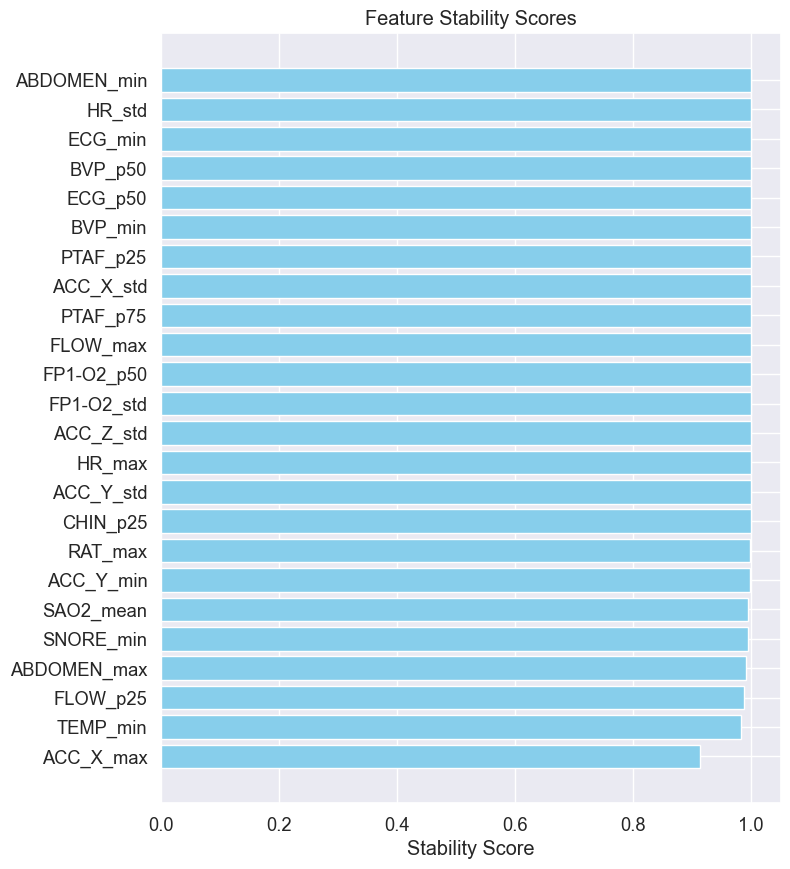

In [31]:
# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.02;
sc=0.9;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(8, 10))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

Number of Salient Features :24


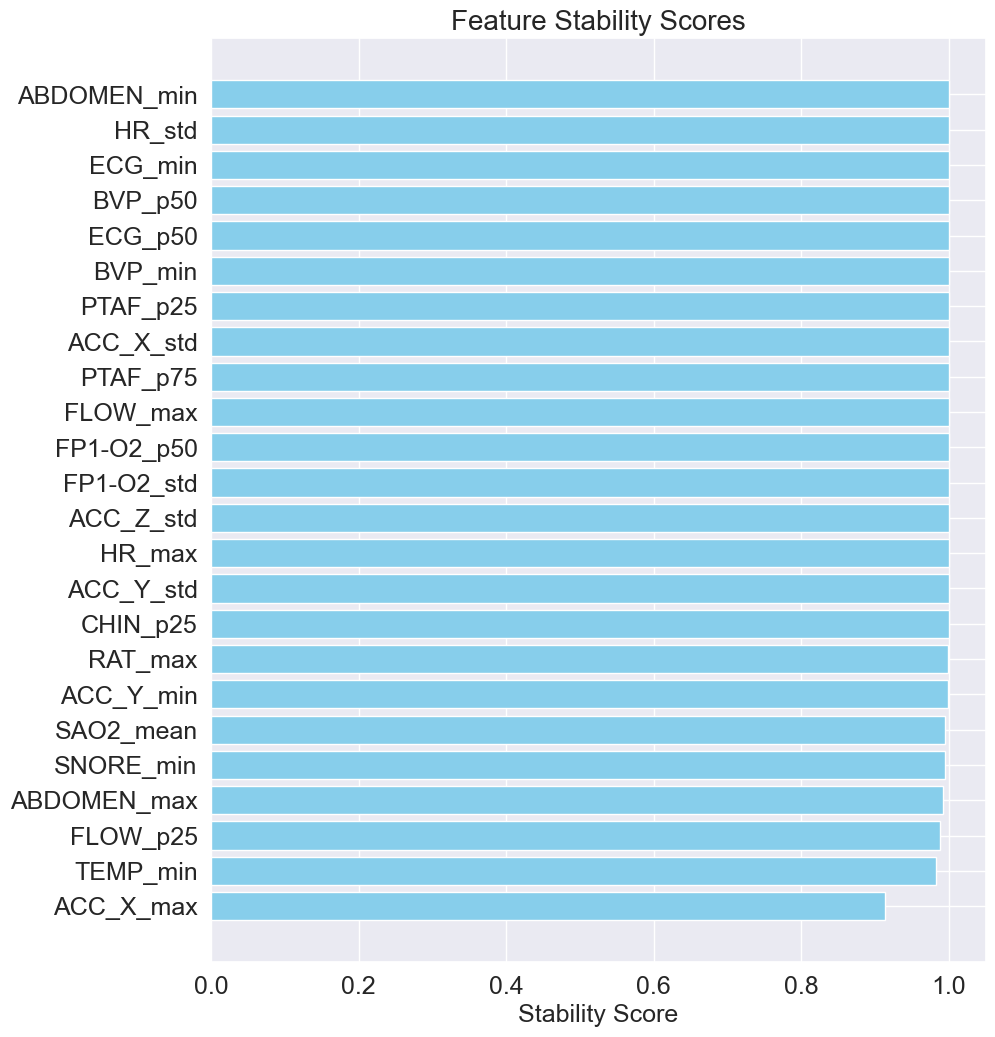

In [41]:

# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.02;
sc=0.9;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(10, 12))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score', fontsize=18)
plt.title('Feature Stability Scores', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

In [27]:
feature_importance_df.shape

(24, 2)

Number of Salient Features :34


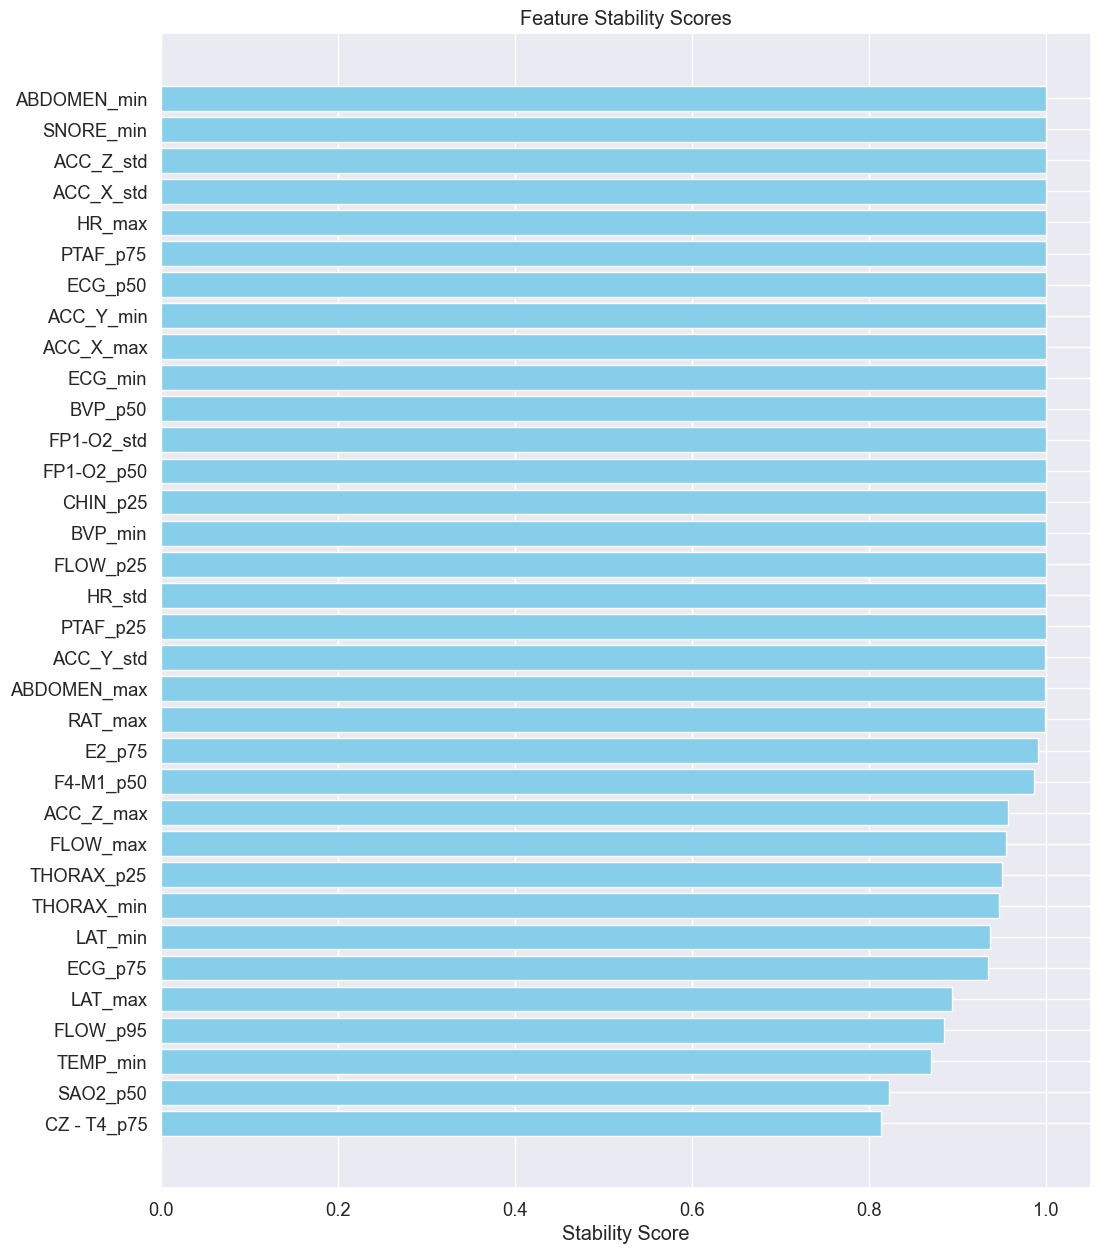

In [57]:
# Plotting the features vs. stability scores
# feature_importance_df=results[0.01]
alpha=0.01;
sc=0.8;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
print(f"Number of Salient Features :{feature_importance_df.shape[0]}")
plt.figure(figsize=(12, 15))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Stability_Score'], color='skyblue')
plt.xlabel('Stability Score')
plt.title('Feature Stability Scores')
plt.gca().invert_yaxis()
# plt.savefig('selected_features_sc9_al_02_acc_v1')
plt.show()

In [47]:
# feature_importance_df[feature_importance_df.Stability_Score>0.6]
# results[0.01]
feature_importance_df.shape

(34, 2)

In [49]:
alpha=0.02;
sc=0.5;
feature_importance_df=results[alpha][results[alpha].Stability_Score>=sc]
feature_importance_df.shape

(30, 2)